In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import datetime
import xgboost as xgb

from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder
#from sklearn.model_selection import train_test_split
#from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Memuat Dataset

In [ ]:
# Membaca CSV dari link download langsung
inventory_df = pd.read_csv('https://drive.google.com/uc?export=download&id=1P2s_8rTCcO839y-d-cpIzbpzNfxMAkf4')

inventory_df.head()

,Date,Item_ID,Item_Name,Category,Subcategory,Unit,Current_Stock,Reorder_Level,Daily_Usage,Lead_Time,Price_per_Unit,Supplier_Name,Seasonal_Factor,Waste_Percentage
0,2025-06-10,1,Paneer,Veg,Dairy,kg,21.45,8.12,2.19,1,450,Supplier A,1.11,2.98
1,2025-06-10,2,Tomato,Veg,Vegetable,kg,12.84,5.34,0.95,4,40,Supplier A,0.81,3.54
2,2025-06-10,3,Onion,Veg,Vegetable,kg,22.35,4.49,4.86,4,35,Supplier A,1.23,4.96
3,2025-06-10,4,Chicken,Non-Veg,Meat,kg,8.36,3.16,3.25,3,250,Supplier C,0.90,3.06
4,2025-06-10,5,Mutton,Non-Veg,Meat,kg,12.31,6.19,1.81,3,600,Supplier A,1.07,3.09


In [ ]:
#melihat tipe data kolom
inventory_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              1000 non-null   object 
 1   Item_ID           1000 non-null   int64  
 2   Item_Name         1000 non-null   object 
 3   Category          1000 non-null   object 
 4   Subcategory       1000 non-null   object 
 5   Unit              1000 non-null   object 
 6   Current_Stock     1000 non-null   float64
 7   Reorder_Level     1000 non-null   float64
 8   Daily_Usage       1000 non-null   float64
 9   Lead_Time         1000 non-null   int64  
 10  Price_per_Unit    1000 non-null   int64  
 11  Supplier_Name     1000 non-null   object 
 12  Seasonal_Factor   1000 non-null   float64
 13  Waste_Percentage  1000 non-null   float64
dtypes: float64(5), int64(3), object(6)
memory usage: 109.5+ KB


In [ ]:
#melihat informasi statistika umum
inventory_df.describe()

,Item_ID,Current_Stock,Reorder_Level,Daily_Usage,Lead_Time,Price_per_Unit,Seasonal_Factor,Waste_Percentage
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.500000,15.80941,6.506350,3.276830,2.510000,183.100000,1.143390,2.446390
std,2.873719,4.60068,2.030039,1.935891,1.131008,195.265508,0.203474,1.428735
min,1.000000,5.77000,3.000000,0.500000,1.000000,6.000000,0.800000,0.030000
25%,3.000000,12.01750,4.737500,1.840000,1.000000,40.000000,0.970000,1.197500
50%,5.500000,16.03500,6.530000,3.000000,3.000000,60.000000,1.140000,2.465000
75%,8.000000,19.41250,8.272500,4.220000,4.000000,280.000000,1.312500,3.670000
max,10.000000,28.90000,9.970000,9.000000,4.000000,600.000000,1.500000,4.990000


# Pembersihan data

In [ ]:
#mengecek missing values
missing_table = pd.DataFrame({
    'missing_count': inventory_df.isnull().sum(),
    'missing_percentage': inventory_df.isnull().sum() / len(inventory_df) * 100
})

missing_table = missing_table[missing_table['missing_count'] > 0]
missing_table.sort_values(by='missing_count', ascending=False)

,missing_count,missing_percentage


In [ ]:
inventory_df['Date'] = pd.to_datetime(inventory_df['Date'])

In [ ]:
item_target = 'Chicken'
df_item = inventory_df[inventory_df['Item_Name'] == item_target].copy()

In [ ]:
df_item = df_item.sort_values(by='Date').reset_index(drop=True)

In [ ]:
prophet_df = df_item[['Date', 'Daily_Usage']].rename(columns={'Date': 'ds', 'Daily_Usage': 'y'})

In [ ]:
if prophet_df['y'].isnull().sum() > 0:
    prophet_df['y'] = prophet_df['y'].interpolate()

In [ ]:
prophet_df.loc[prophet_df['y'] < 0, 'y'] = 0

In [ ]:
Q1 = prophet_df['y'].quantile(0.25)
Q3 = prophet_df['y'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

In [ ]:
prophet_df.loc[prophet_df['y'] > upper_bound, 'y'] = upper_bound

print(f"\n--- Data {item_target} yang Siap Dimasukkan ke Prophet ---")
display(prophet_df.head())


--- Data Chicken yang Siap Dimasukkan ke Prophet ---


,ds,y
0,2025-06-10,3.25
1,2025-06-11,2.28
2,2025-06-12,2.42
3,2025-06-13,1.12
4,2025-06-14,2.72


In [ ]:
prophet_df.loc[prophet_df['y'] > upper_bound, 'y'] = upper_bound

print(f"\n--- Data {item_target} yang Siap Dimasukkan ke Prophet ---")
display(prophet_df.head())


--- Data Chicken yang Siap Dimasukkan ke Prophet ---


,ds,y
0,2025-06-10,3.25
1,2025-06-11,2.28
2,2025-06-12,2.42
3,2025-06-13,1.12
4,2025-06-14,2.72


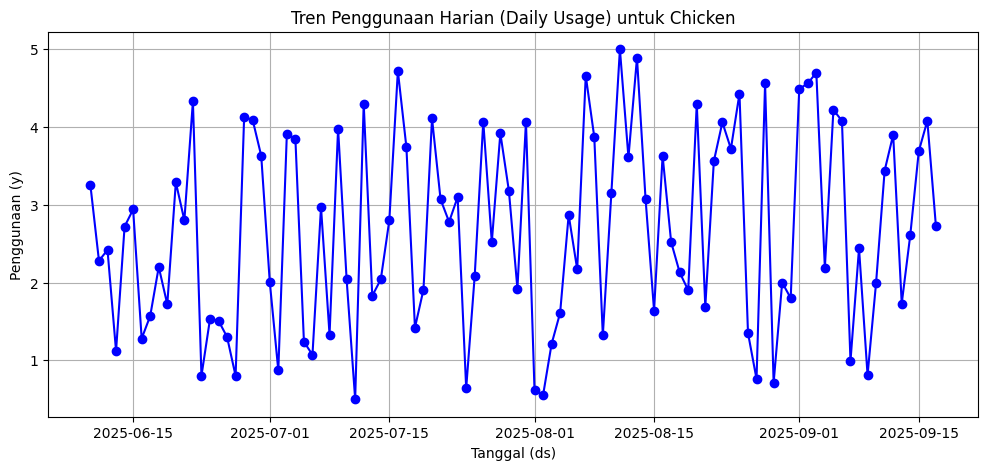

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(prophet_df['ds'], prophet_df['y'], marker='o', linestyle='-', color='b')
plt.title(f'Tren Penggunaan Harian (Daily Usage) untuk {item_target}')
plt.xlabel('Tanggal (ds)')
plt.ylabel('Penggunaan (y)')
plt.grid(True)
plt.show()

In [ ]:
from prophet import Prophet

model = Prophet(weekly_seasonality=True, yearly_seasonality=False, daily_seasonality=False)

print(f"Sedang melatih model untuk {item_target}...")
model.fit(prophet_df) # Memasukkan data bersih kita ke dalam algoritma
print("Pelatihan selesai!\n")

Sedang melatih model untuk Chicken...
Pelatihan selesai!



In [ ]:
hari_ke_depan = 30
future = model.make_future_dataframe(periods=hari_ke_depan)

forecast = model.predict(future)

print(f"--- Cuplikan Hasil Prediksi {hari_ke_depan} Hari Ke Depan ---")
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

--- Cuplikan Hasil Prediksi 30 Hari Ke Depan ---


,ds,yhat,yhat_lower,yhat_upper
125,2025-10-13,3.462771,1.968381,4.998443
126,2025-10-14,3.098433,1.533492,4.549136
127,2025-10-15,3.358737,1.832060,4.872348
128,2025-10-16,3.390247,1.828322,4.935634
129,2025-10-17,2.943989,1.463669,4.544204



--- Grafik Prediksi (Forecasting) ---


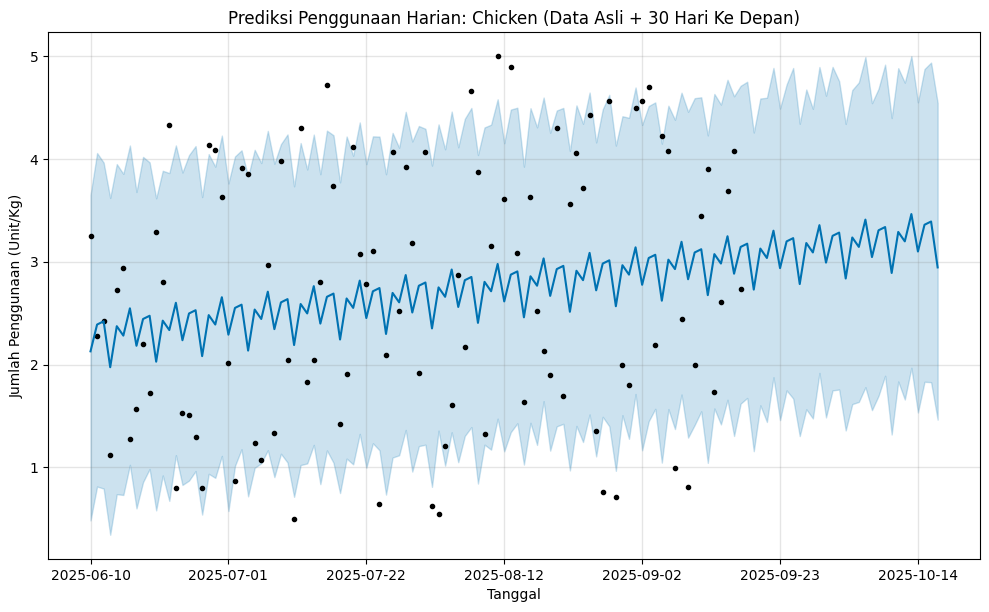

In [ ]:
print("\n--- Grafik Prediksi (Forecasting) ---")
fig1 = model.plot(forecast)
plt.title(f'Prediksi Penggunaan Harian: {item_target} (Data Asli + 30 Hari Ke Depan)')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Penggunaan (Unit/Kg)')
plt.show()


--- Analisis Pola (Tren & Musiman Mingguan) ---


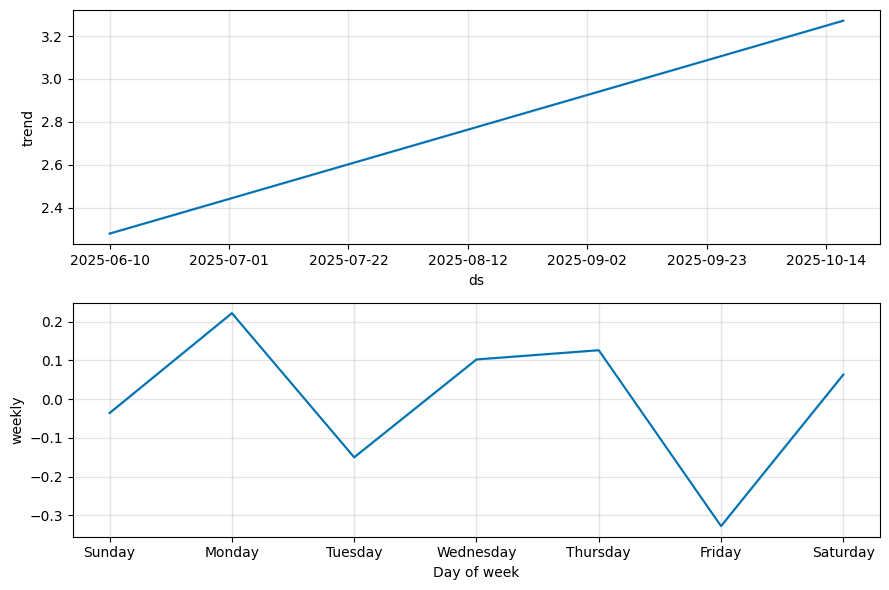

In [ ]:
print("\n--- Analisis Pola (Tren & Musiman Mingguan) ---")
fig2 = model.plot_components(forecast)
plt.show()

In [ ]:
import json
from prophet.serialize import model_to_json

In [ ]:
nama_file_model = f'model_prophet_{item_target.lower()}.json'

In [ ]:
with open(nama_file_model, 'w') as fout:
    json.dump(model_to_json(model), fout)

print(f"✅ Model berhasil diekspor dan disimpan dengan nama: {nama_file_model}")

✅ Model berhasil diekspor dan disimpan dengan nama: model_prophet_chicken.json


In [ ]:
from google.colab import files
files.download(nama_file_model)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>